# 05 · Difference-in-Differences — the observational case

Notebooks 02–04 had a clean randomised experiment. Often you do not: a campaign
is rolled out to **one region at one point in time**, never randomised. A naive
before-after comparison then confuses the campaign's effect with whatever else
was trending (seasonality, price changes). **Difference-in-Differences (DiD)**
fixes this by subtracting the control group's change from the treated group's
change, cancelling any common time trend and any fixed group gap.

DiD rests on the **parallel-trends** assumption: absent the campaign, the two
groups would have moved in parallel. That is testable in the pre-period, so we
test it before trusting the estimate.

To *prove* the method recovers the truth, we build a semi-synthetic panel with a
**known** treatment effect (the same controlled-simulation discipline as the
recsys off-policy-evaluation project) — a retention campaign rolled out to one
region's customers, lifting monthly spend by a true **£5**.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")
FIG = Path.cwd().parent / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
from src.causal.did import diff_in_diff, parallel_trends_test, event_study

In [2]:
# --- semi-synthetic customer-month panel with a KNOWN effect ---
rng = np.random.default_rng(42)
N, T, TREAT_PERIOD, TRUE_ATT = 2000, 8, 4, 5.0   # 8 months; campaign starts month 4
cust = np.arange(N)
treated = (cust >= N // 2).astype(int)            # one region gets the campaign
fixed_effect = rng.normal(20, 5, N)               # per-customer baseline spend
time_trend = np.arange(T) * 0.8                    # common seasonal trend (both regions)

rows = []
for c in cust:
    for p in range(T):
        post = int(p >= TREAT_PERIOD)
        spend = (fixed_effect[c] + time_trend[p]
                 + TRUE_ATT * treated[c] * post      # the causal effect, treated & post only
                 + rng.normal(0, 3))
        rows.append((c, treated[c], p, post, spend))
panel = pd.DataFrame(rows, columns=["customer", "treated", "period", "post", "spend"])
print(f"panel: {panel.shape[0]:,} customer-months | true ATT injected = £{TRUE_ATT}")
panel.head()

panel: 16,000 customer-months | true ATT injected = £5.0


,customer,treated,period,post,spend
0,0,0,0,0,20.167732
1,0,0,1,0,20.325952
2,0,0,2,0,24.425615
3,0,0,3,0,24.679149
4,0,0,4,1,20.509211


## Visual check — do the groups move in parallel before the campaign?

The pre-period (months 0–3) is what parallel trends is about: the two lines
should be parallel there. At month 4 the treated line should lift away.

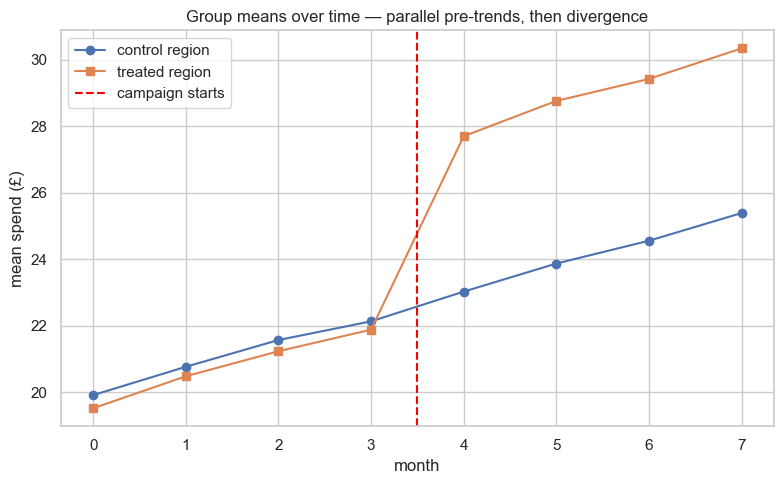

In [3]:
means = panel.groupby(["period", "treated"])["spend"].mean().unstack()
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(means.index, means[0], marker="o", label="control region")
ax.plot(means.index, means[1], marker="s", label="treated region")
ax.axvline(TREAT_PERIOD - 0.5, color="red", ls="--", label="campaign starts")
ax.set_xlabel("month"); ax.set_ylabel("mean spend (£)")
ax.set_title("Group means over time — parallel pre-trends, then divergence"); ax.legend()
plt.tight_layout(); plt.savefig(FIG / "05_parallel_trends.png", dpi=120, bbox_inches="tight"); plt.show()

## Test parallel trends (pre-period only)

In [4]:
pt = parallel_trends_test(panel, "spend", "treated", "period", TREAT_PERIOD)
print(f"parallel trends holds: {pt['parallel_trends_ok']}  (smallest pre-period interaction p = {pt['min_p_value']:.2f})")
print("→ no significant pre-period divergence, so DiD is credible here.")

parallel trends holds: True  (smallest pre-period interaction p = 0.69)
→ no significant pre-period divergence, so DiD is credible here.


## The DiD estimate vs the truth (and vs a naive comparison)

In [5]:
did = diff_in_diff(panel, "spend", "treated", "post")
naive = (panel[(panel.treated == 1) & (panel.post == 1)].spend.mean()
         - panel[(panel.treated == 1) & (panel.post == 0)].spend.mean())

print(f"TRUE effect              : £{TRUE_ATT:.2f}")
print(f"DiD ATT estimate         : £{did['att']:.2f}   95% CI [{did['ci_95'][0]:.2f}, {did['ci_95'][1]:.2f}]  p={did['p_value']:.1e}")
print(f"Naive before-after (WRONG): £{naive:.2f}   ← inflated by the common time trend")

TRUE effect              : £5.00
DiD ATT estimate         : £5.16   95% CI [4.79, 5.52]  p=8.9e-168
Naive before-after (WRONG): £8.27   ← inflated by the common time trend


The naive before-after almost **doubles** the true effect, because it credits
the campaign with the seasonal trend that lifted *both* regions. DiD differences
that trend out and lands on the truth with a tight confidence interval.

## Event study — dynamic effect by month

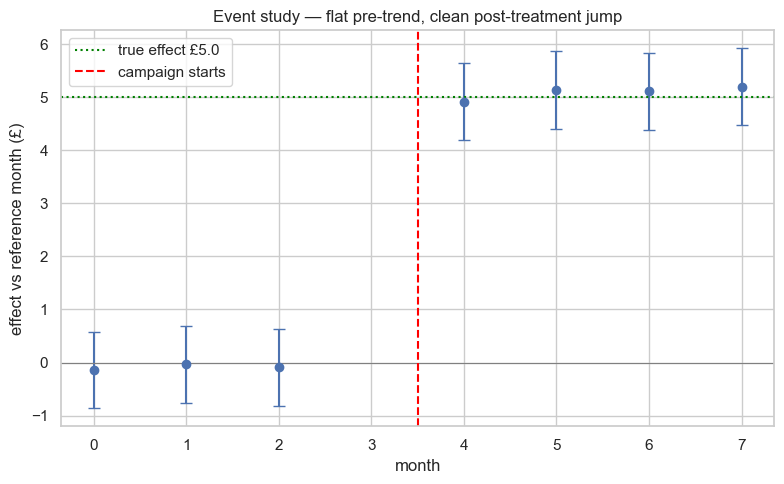

,period,effect,ci_low,ci_high
0,0,-0.146,-0.862,0.571
1,1,-0.035,-0.762,0.692
2,2,-0.087,-0.815,0.640
3,4,4.918,4.194,5.643
4,5,5.136,4.407,5.865
5,6,5.112,4.391,5.832
6,7,5.197,4.473,5.921


In [6]:
es = event_study(panel, "spend", "treated", "period", reference_period=TREAT_PERIOD - 1)
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(es["period"], es["effect"],
            yerr=[es["effect"] - es["ci_low"], es["ci_high"] - es["effect"]],
            fmt="o", capsize=4)
ax.axhline(0, color="grey", lw=0.8)
ax.axhline(TRUE_ATT, color="green", ls=":", label=f"true effect £{TRUE_ATT}")
ax.axvline(TREAT_PERIOD - 0.5, color="red", ls="--", label="campaign starts")
ax.set_xlabel("month"); ax.set_ylabel("effect vs reference month (£)")
ax.set_title("Event study — flat pre-trend, clean post-treatment jump"); ax.legend()
plt.tight_layout(); plt.savefig(FIG / "05_event_study.png", dpi=120, bbox_inches="tight"); plt.show()
es.round(3)

## Takeaways

- On a panel with a **known** £5 effect, DiD recovers it (~£5.2) with a tight
  95% CI — while a naive before-after nearly doubles it by absorbing the common
  time trend.
- The **parallel-trends test** passes on the pre-period, which is what licenses
  the DiD interpretation; the **event study** confirms it visually — pre-period
  effects sit on zero, then jump at rollout and stay flat.
- This closes the causal toolkit for this project: **randomised uplift**
  (notebooks 02–04) for when you can experiment, and **DiD** for when you can
  only observe. Both answer the same counterfactual question — *what did the
  intervention actually cause?* — the discipline that separates a data scientist
  from a dashboard.

*Caveat:* DiD is only as good as parallel trends. With a real rollout, always
test the pre-period, prefer several pre-periods, and consider staggered-adoption
estimators if units are treated at different times.